In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def sho_expects(del_t,period_number, eta, k, gamma, x0, p0):
    

    #We will multiply all values by scale values at the end to get real values 
    #Real params 
    w1_real = 50000 * 2*np.pi  #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #Js
     
    x = x0
    p = p0
    exp_x, exp_p,exp_x_sq,exp_p_sq = [x], [p], [0],[0]
    
    
    #Define scale values such that w1, m are 1
    w1_scale = w1_real
    m_scale = m_bead
    
    #Define scale factors for position and momentum 
    x_scale = np.sqrt(hbar/(m_scale*w1_scale))
    p_scale = np.sqrt(hbar*m_scale*w1_scale)
    t_scale = 1/w1_scale
    

    w1 = w1_real/w1_scale
    m = m_bead/m_scale
    
    epsilon = -2*gamma/w1
    
    T = (2*np.pi)/w1
    t = period_number*T
    
    steps = int(t/del_t)
    t_arr = np.linspace(0, t, steps)
    t_per_arr = t_arr/T
    
    
    alpha_x_stream = [0]
    alpha_p_stream = []
    
    var_x = 1/(2*m*w1)
    var_p = m*w1/2
    cov_xp = 0

    
    w_sq = w1**2*(1 - 2*epsilon)
    phi = np.arctan(p/x)
    phi_p = np.pi/2 - 2*phi
    
    w_sq_list = [w_sq]
    phi_p_list = [phi_p]
    X_rot = x
    Y_rot = p
    
    phi_p_rot_list = [phi_p]
    for i in range(steps-1):
        del_W = np.random.normal(loc=0.0, scale=np.sqrt(del_t), size=None)

        
        x += (1/m*p*del_t) + (np.sqrt(8*eta*k)*var_x*del_W) 
        p += (-m* w_sq*x*del_t) + (np.sqrt(8*eta*k)*cov_xp*del_W)
        
        var_x += ((2/m*cov_xp) - (8*eta*k*var_x**2)) * del_t
        var_p += ((-2*m*w_sq*cov_xp) + 2*k - (8*eta*k*cov_xp**2)) * del_t
        cov_xp += (1/m*var_p - m*w_sq*var_x - (8*eta*k*var_x*cov_xp)) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2 
        
        alpha_x = x + (del_W/(np.sqrt(8*eta*k*del_t)))
        alpha_x_stream.append(alpha_x)
        
        if i > 50:
            alpha_p = m*(alpha_x_stream[i] - alpha_x_stream[i-1])/del_t
            alpha_p_stream.append(alpha_p)
        
       
        exp_x.append(x)
        exp_p.append(p)
        
        exp_x_sq.append(x_sq)
        exp_p_sq.append(p_sq)
        

        phi = np.arctan(p/x)
        phi_p = np.pi/2 - 2*phi
        
        w_sq = w1**2*(1 - 2*epsilon*np.cos(2*w1*t_arr[i]+phi_p))
        w_sq_list.append(w_sq)
        phi_p_list.append(phi_p)
        
        X_rot = x*np.cos(w1*t_arr[i]) + p*np.sin(w1*t_arr[i])
        Y_rot = -x*np.sin(w1*t_arr[i]) + p*np.cos(w1*t_arr[i])
        
        phi_rot = np.arctan(Y_rot/X_rot)
        phi_p_rot = np.pi/2 - 2*phi_rot
        phi_p_rot_list.append(phi_p_rot)
        
        
    t_real_arr = t_arr *t_scale
    exp_x_real  = np.array(exp_x) * x_scale
    exp_p_real  = np.array(exp_p) * p_scale
    exp_x_sq_real = np.array(exp_x_sq) * x_scale**2
    exp_p_sq_real = np.array(exp_p_sq) * p_scale**2

    var_x_real = var_x * x_scale**2
    var_p_real = var_p * p_scale**2
    cov_xp_real = cov_xp * x_scale * p_scale
    
    alpha_x_stream_real = np.array(alpha_x_stream) * x_scale
    alpha_p_stream_real = np.array(alpha_p_stream) * p_scale
    w_sq_arr_real = np.array(w_sq_list)* ((2*np.pi)/t_scale)**2 
    
    return [t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real,w_sq_arr_real,np.array(phi_p_list), phi_p_rot_list]
 

In [38]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real,w_sq_list,phi_p_list, phi_p_rot_list = sho_expects(del_t=0.1,period_number=1000, eta=1, k=0.05, gamma=0, x0=20, p0=20)

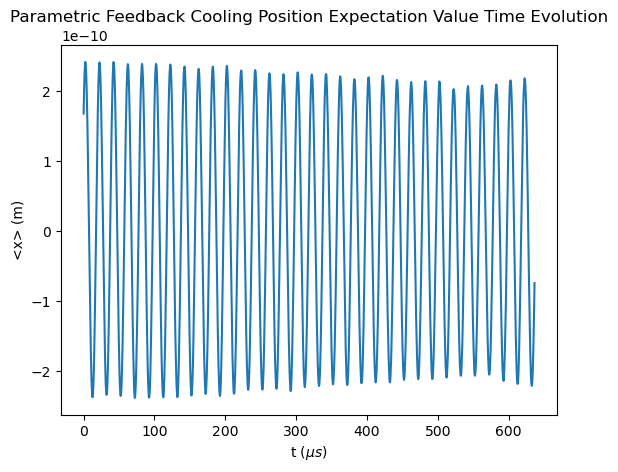

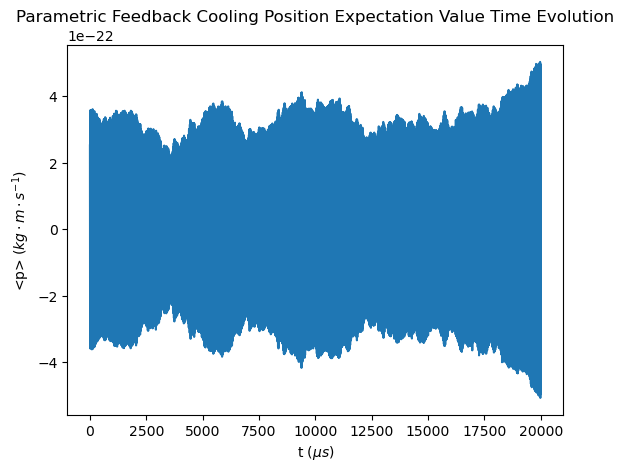

In [39]:
plt.figure()
plt.plot(t_real_arr[:2000]*10**6, exp_x_real[:2000])
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Parametric Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Parametric Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

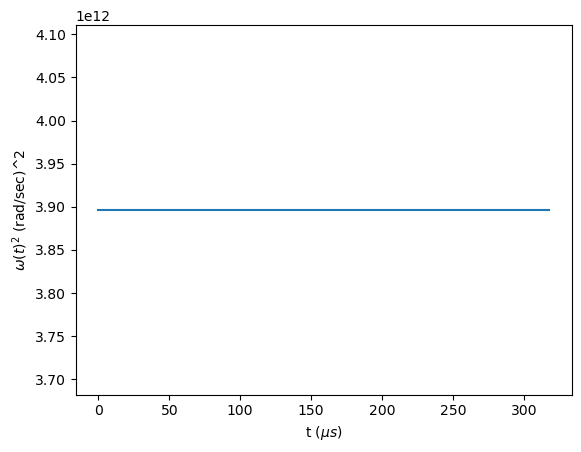

In [40]:
plt.figure()
plt.plot((t_real_arr[:1000])*10**6, np.array(w_sq_list[:1000]))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\omega(t)^2$ (rad/sec)^2")
plt.show()

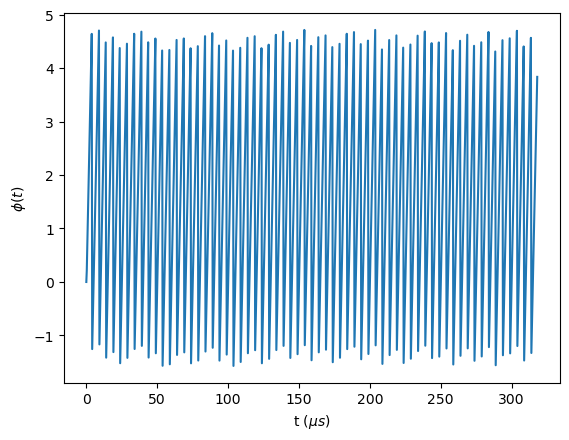

In [41]:
plt.figure()
plt.plot((t_real_arr[:1000])*10**6, np.array(phi_p_rot_list[:1000]))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\phi(t)$")
plt.show()

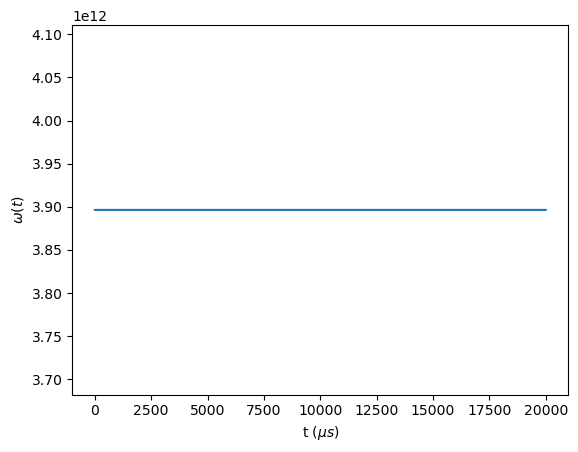

In [44]:
plt.figure()
plt.plot((t_real_arr)*10**6, np.array(w_sq_list))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\omega(t)$")
plt.show()

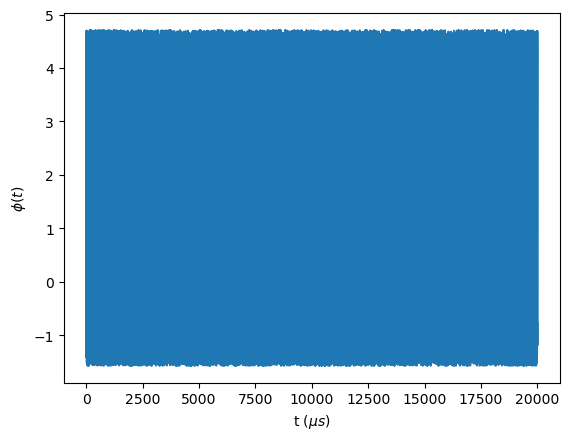

In [45]:
plt.figure()
plt.plot((t_real_arr)*10**6, np.array(phi_p_rot_list))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\phi(t)$")
plt.show()